In [2]:
import xarray as xr
import s3fs
import zarr

print(xr.__version__)
print(zarr.__version__)
print(s3fs.__version__)


2026.1.0
3.1.5
2025.12.0


In [1]:
store = "https://objects.eodc.eu/68e13833a1624f43ba2cac01376a18af:destine-climate-dt/IFS-NEMO_sfc_ScenarioMIP_SSP3-7.0_snowDepth.zarr"

In [5]:
zstore = xr.open_zarr(store, chunks=100)
zstore

/tmp/ipykernel_15448/2944451101.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "t" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  zstore = xr.open_zarr(store, chunks=100)


<xarray.Dataset> Size: 4GB
Dimensions:    (pointid: 11836, levelist: 1, number: 1, datetime: 1, t: 43848)
Coordinates:
  * pointid    (pointid) int64 95kB 21 8 0 1 11 ... 11838 11837 11850 11834
    latitude   (pointid) float64 95kB dask.array<chunksize=(100,), meta=np.ndarray>
    longitude  (pointid) float64 95kB dask.array<chunksize=(100,), meta=np.ndarray>
  * levelist   (levelist) int64 8B 0
  * number     (number) int64 8B 0
  * datetime   (datetime) <U20 80B '2024-12-31 00:00:00Z'
  * t          (t) datetime64[ns] 351kB 2020-01-01 ... 2024-12-31T23:00:00
Data variables:
    sd         (pointid, levelist, number, datetime, t) float64 4GB dask.array<chunksize=(100, 1, 1, 1, 100), meta=np.ndarray>
Attributes: (12/14)
    activity:       scenariomip
    class:          d1
    dataset:        climate-dt
    experiment:     ssp3-7.0
    expver:         0001
    generation:     1
    ...             ...
    realization:    1
    resolution:     high
    stream:         clte
    type:           fc
    number:         0
    Forecast date:  2024-12-31 00:00:00Z

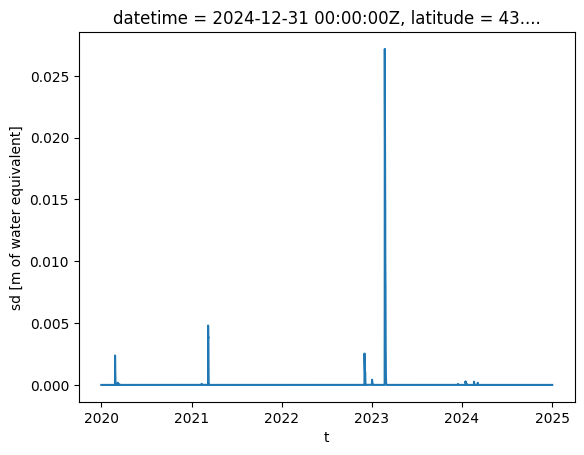

In [7]:
zstore["sd"].isel(pointid=1400).plot()

In [52]:
test_store = "../dt_climate-zarr-save/WeatherStations/IFS-NEMO_sfc_CMIP6_hist.zarr/"

In [53]:
zstore_test = xr.open_zarr(test_store, chunks="auto")
zstore_test

<xarray.Dataset> Size: 2GB
Dimensions:    (stationid: 629, latitude: 1, longitude: 1, levelist: 1,
                number: 1, datetime: 1, t: 106608)
Coordinates:
  * stationid  (stationid) int64 5kB 18 5 20 14 16 ... 14520 15600 19600 20210
  * latitude   (latitude) float64 8B 46.67
  * longitude  (longitude) float64 8B 14.34
  * levelist   (levelist) int64 8B 0
  * number     (number) int64 8B 0
  * datetime   (datetime) <U20 80B '2002-02-28 00:00:00Z'
  * t          (t) datetime64[ns] 853kB 1990-01-01 ... 2002-02-28T23:00:00
Data variables:
    2t         (stationid, latitude, longitude, levelist, number, datetime, t) float64 536MB dask.array<chunksize=(157, 1, 1, 1, 1, 1, 106608), meta=np.ndarray>
    sd         (stationid, latitude, longitude, levelist, number, datetime, t) float64 536MB dask.array<chunksize=(157, 1, 1, 1, 1, 1, 106608), meta=np.ndarray>
    tp         (stationid, latitude, longitude, levelist, number, datetime, t) float64 536MB dask.array<chunksize=(157, 1, 1, 1, 1, 1, 106608), meta=np.ndarray>
    tprate     (stationid, latitude, longitude, levelist, number, datetime, t) float64 536MB dask.array<chunksize=(157, 1, 1, 1, 1, 1, 106608), meta=np.ndarray>
Attributes: (12/14)
    activity:       cmip6
    class:          d1
    dataset:        climate-dt
    experiment:     hist
    expver:         0001
    generation:     1
    ...             ...
    realization:    1
    resolution:     high
    stream:         clte
    type:           fc
    number:         0
    Forecast date:  2002-02-28 00:00:00Z

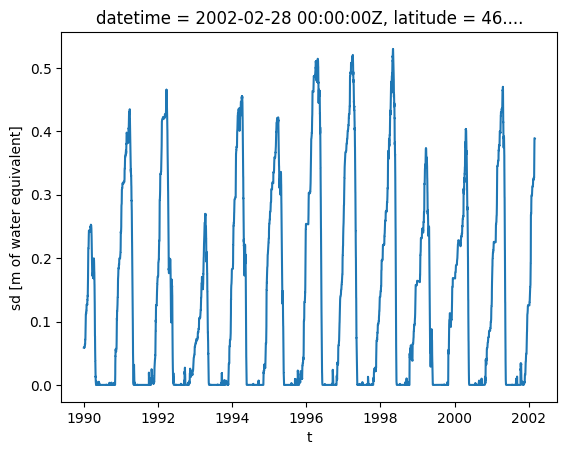

In [56]:
zstore_test["sd"].isel(stationid=78).plot()

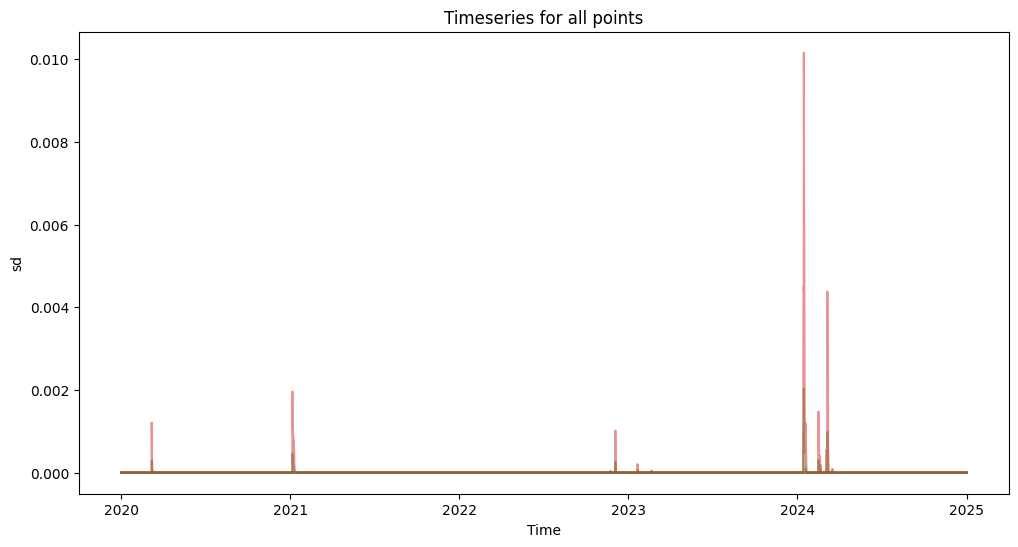

In [43]:
import matplotlib.pyplot as plt

da = zstore_test["sd"].squeeze()

plt.figure(figsize=(12, 6))
da.plot.line(x="t", hue="pointid", alpha=0.5, add_legend=False)

plt.xlabel("Time")
plt.ylabel("sd")
plt.title("Timeseries for all points")
plt.show()

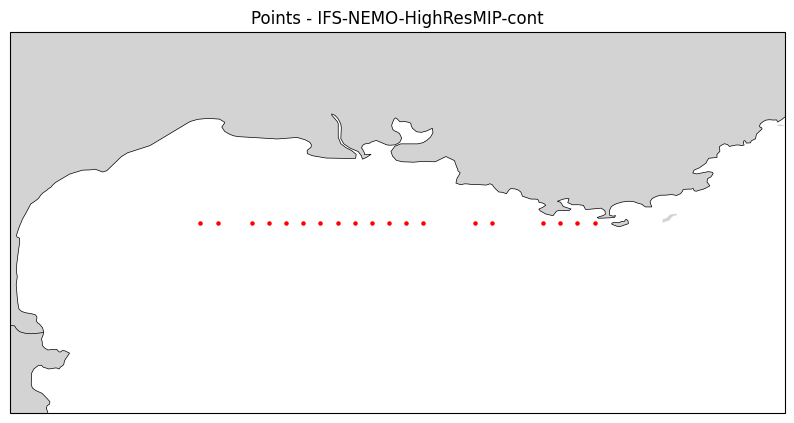

In [51]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

ds = zstore
lats = ds.latitude.values
lons = ds.longitude.values

fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

ax.scatter(
    lons, lats,
    transform=ccrs.PlateCarree(),
    s=5, color="red", zorder=5
)

ax.set_extent([lons.min()-1, lons.max()+1, lats.min()-1, lats.max()+1])
plt.title("Points - IFS-NEMO-HighResMIP-cont")
plt.show()

## Open zarr store with s3fs

In [ ]:
eodc_s3 = s3fs.S3FileSystem(
    key="",
    secret="",
    client_kwargs={
        "endpoint_url": "https://objects.eodc.eu"
    })
 
# climatedt_zarr = s3fs.S3Map(root="destine-climate-dt/climate-dt.zarr", s3=eodc_s3)
climatedt_zarr = s3fs.S3Map(root="destine-climate-dt/climate-dt.zarr", s3=eodc_s3)
print(climatedt_zarr)
# zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-NEMO-HighResMIP-cont", chunks="auto",)
# zstore_timedim["2t"].isel(points=102).plot()

In [72]:
zstore_nemo = xr.open_zarr(climatedt_zarr, group="IFS-FESOM-story-nudging-cont", chunks=100)
zstore_nemo

/tmp/ipykernel_8037/2308541435.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "datetimes" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  zstore_nemo = xr.open_zarr(climatedt_zarr, group="IFS-FESOM-story-nudging-cont", chunks=100)
/tmp/ipykernel_8037/2308541435.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "points" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  zstore_nemo = xr.open_zarr(climatedt_zarr, group="IFS-FESOM-story-nudging-cont", chunks=100)


<xarray.Dataset> Size: 4GB
Dimensions:    (datetimes: 438288, points: 629)
Coordinates:
  * datetimes  (datetimes) datetime64[ns] 4MB 1990-01-01 ... 2039-12-31T23:00:00
  * points     (points) int64 5kB 0 1 2 3 4 5 6 ... 622 623 624 625 626 627 628
    latitude   (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
    longitude  (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
Data variables:
    2t         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>
    tp         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>

In [81]:
store = zarr.open(climatedt_zarr, mode="r")
store.tree()

/
├── IFS-FESOM-story-nudging-Tplus2.0K
│   ├── 2t (438288, 629) float64
│   ├── datetimes (438288,) int64
│   ├── latitude (629,) float64
│   ├── longitude (629,) float64
│   ├── points (629,) int64
│   └── tp (438288, 629) float64
├── IFS-FESOM-story-nudging-cont
│   ├── 2t (438288, 629) float64
│   ├── datetimes (438288,) int64
│   ├── latitude (629,) float64
│   ├── longitude (629,) float64
│   ├── points (629,) int64
│   └── tp (438288, 629) float64
├── IFS-FESOM-story-nudging-hist
│   ├── 2t (438288, 629) float64
│   ├── datetimes (438288,) int64
│   ├── latitude (629,) float64
│   ├── longitude (629,) float64
│   ├── points (629,) int64
│   └── tp (438288, 629) float64
├── IFS-NEMO-CMIP6-hist
│   ├── 2t (438288, 629) float64
│   ├── datetimes (438288,) int64
│   ├── latitude (629,) float64
│   ├── longitude (629,) float64
│   ├── points (629,) int64
│   └── tp (438288, 629) float64
├── IFS-NEMO-HighResMIP-cont
│   ├── 2t (438288, 629) float64
│   ├── datetimes (438288,) int64
│   ├── latitude (629,) float64
│   ├── longitude (629,) float64
│   ├── points (629,) int64
│   └── tp (438288, 629) float64
└── IFS-NEMO-ScenarioMIP-SSP3-7.0
    ├── 2t (438288, 629) float64
    ├── datetimes (438288,) int64
    ├── latitude (629,) float64
    ├── longitude (629,) float64
    ├── points (629,) int64
    └── tp (438288, 629) float64